In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
#from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm
import xesmf as xe

RUN FROM HERE

In [2]:
z500_SON=xr.open_dataset('~/work/ERA5_dyn_data_ready/z500_SON.nc')
z500_DJF=xr.open_dataset('~/work/ERA5_dyn_data_ready/z500_DJF.nc')

Import driver data

In [3]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('../data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('../data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('../data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('../data_ready/4.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 6kB
Dimensions:        (year: 72)
Coordinates:
  * year           (year) int64 576B 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t_Andes        (year) float64 576B -1.791 0.5614 -0.2617 ... 0.7645 0.6017
    precip_Andes   (year) float64 576B 0.129 0.4549 -1.375 ... -0.2223 -1.51
    ENSO           (year) float64 576B -0.6866 0.5838 0.3068 ... -0.7546 1.632
    IOD            (year) float64 576B 0.2555 0.6281 1.26 ... 0.9651 4.209
    EDJ            (year) float64 576B 1.783 0.6677 -0.5056 ... 0.9377 0.1875
    EDJ_lat        (year) float64 576B -0.6985 1.359 -0.9556 ... -2.241 -2.241
    EDJ_lat_nostd  (year) float64 576B -52.07 -48.64 -52.5 ... -54.64 -54.64
    SPV            (year) float64 576B 0.2633 -0.6312 1.451 ... 2.242 1.702 1.85
    A_SAM          (year) float64 576B 0.233 -1.135 -2.197 ... 1.774 0.05365
    S_SAM          (year) float64 576B 0.6038 -1.058 0.1437 ... 1.631 1.93 1.88

In [4]:
##SON data
ds_SON = xr.merge([z500_SON, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([z500_DJF, era_DJF_LaPlata_array])

In [5]:
display(ds_SON)

<xarray.Dataset> Size: 19MB
Dimensions:         (lon: 360, lat: 90, year: 72)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    Z500            (year, lat, lon) float64 19MB ...
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

Regressions and Maps

In [6]:
def construct_da_x_year_fix(ds, size=30):
    ##this is a very confusing method, but I trust that it works...
    ds_roll=ds.rolling(year=size, center=False).construct("window")
    ds_roll_full=ds_roll.isel(year=slice(size-1, None))  # drop incomplete windows
    ds_chunked=ds_roll_full.chunk(lat=int(len(ds.lat)/4),lon=int(len(ds.lon)/4),year=-1)
    return ds_chunked

def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    mask = ~np.isnan(y) & ~np.any(np.isnan(X), axis=1)
    #print(mask.sum())
    # require a reasonable sample size (NOT just n_predictors)
    if mask.sum() < 20:   # <-- THIS is crucial
        return np.nan

    X = X[mask]
    y = y[mask]

    try:
        return np.linalg.lstsq(X, y, rcond=None)[0][0]
    except:
        return np.nan
    
    
def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False, whole_period=True):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None
        if whole_period==True:

            if controls is not None:
                x_controls = [ds_rolled[var] for var in controls]
            else:
                x_controls = []
            
            coef = xr.apply_ufunc(
                lin_model_fast,
                ds_rolled[target],
                ds_rolled[driver],
                *x_controls,
                input_core_dims=[["year"], ["year"]] + [["year"]] * len(x_controls),
                #input_core_dims=[["year"]] * (2 + len(x_controls)),
                output_core_dims=[[]],
                vectorize=True,
                dask="parallelized",
                output_dtypes=[float],
            )
            mean_coef=coef
        else:
            coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
            )

            mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

In [7]:
import cartopy.feature as cfeature
def modified_colorbar(cmap, levels, center_zero=True):
    n = len(levels) - 1
    colors = cmap(np.linspace(0, 1, n))
    
    if center_zero:
        mid = n // 2
        if n % 2 == 0: ##for even number of levels, set the two middle colors to white
            colors[mid-1:mid+1] = [1, 1, 1, 1]
        else:
            colors[mid] = np.array([1, 1, 1, 1])  # white
    
    return mcolors.ListedColormap(colors)

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(subplts_num, 1, i, projection=ccrs.PlateCarree(central_longitude=-130)) 
    ##changed cols and rows here for circulation maps

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    if levels is None:
        levels = np.arange(-3, 3.01, 0.5)  # include +3
    cmap_mod=modified_colorbar(cmap, levels, center_zero=True)
    norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

    
    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap_mod)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap_mod, shading="auto")
        

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.01, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_ticks(levels)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.RdBu.reversed(), unit='K', steps=0.1, cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)

    #Define levels for colorbar later
    step = steps # or 0.25 if you prefer
    max_abs = np.ceil(global_max / step) * step
    #print(max_abs)
    levels = np.arange(-max_abs, max_abs + step, step)  
     
    ##Find optimal figsize
    width_per_plot = 12
    height = 5

    fig = plt.figure(figsize=(width_per_plot, len(ds)*height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        levels=levels,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    #if global_max>levels[-1]: #if the global max exceeds the provided levels, we need to adjust them
    
    
    if not cbar_each:
        #modify colorbar
        cmap_mod = modified_colorbar(cmap, levels, center_zero=True)

        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap_mod.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap_mod)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        ticks = np.arange(-max_abs, max_abs + step, step*2)  
        cbar.set_ticks(ticks)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
                
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.00001, fontweight='bold', fontsize=18)
        fig.savefig('target_maps_whole/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

In [8]:
display(ds_SON)

<xarray.Dataset> Size: 19MB
Dimensions:         (lon: 360, lat: 90, year: 72)
Coordinates:
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * lat             (lat) float64 720B -89.5 -88.5 -87.5 ... -2.5 -1.5 -0.5
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    Z500            (year, lat, lon) float64 19MB ...
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

In [9]:
z500_IOD_A_SAM_SON=conditioning_everything_fast(ds_SON, ['IOD', 'A_SAM'], 'Z500')

IOD done
A_SAM done


In [10]:
z500_IOD_A_SAM_SON=[m.compute() for m in z500_IOD_A_SAM_SON]

In [11]:
z500_IOD_A_SAM_SON

[<xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.12825011, 0.12837161, 0.12850011, ..., 0.12803145, 0.12811684,
         0.12823647],
        [0.14145194, 0.1417902 , 0.14212645, ..., 0.14049071, 0.14083468,
         0.14110983],
        [0.15276755, 0.15334362, 0.15387098, ..., 0.15104828, 0.15164776,
         0.15224595],
        ...,
        [0.03009957, 0.02985803, 0.02986448, ..., 0.03039575, 0.03031909,
         0.03014228],
        [0.03016712, 0.02991499, 0.02992877, ..., 0.0303839 , 0.03046007,
         0.03029859],
        [0.03003817, 0.02986809, 0.02999953, ..., 0.03025698, 0.03036642,
         0.03028942]], shape=(90, 360))
 Coordinates:
   * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
   * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5,
 <xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[ 0.00202978,  0.00228452,  0.00253267, ...,  0.00134503,
          0.00155989,  0.00183134],
        [

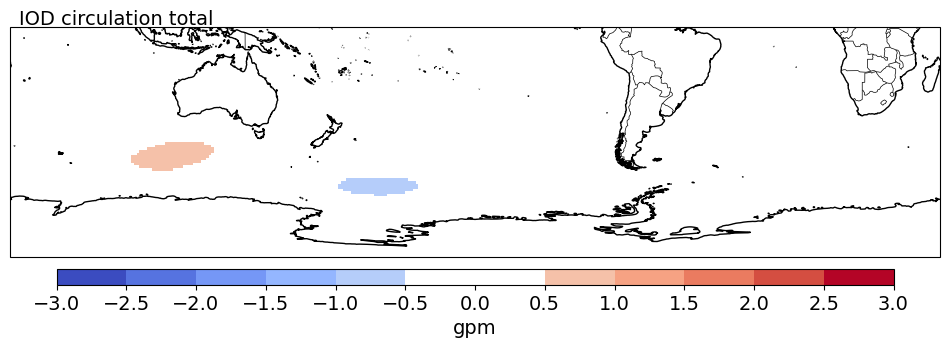

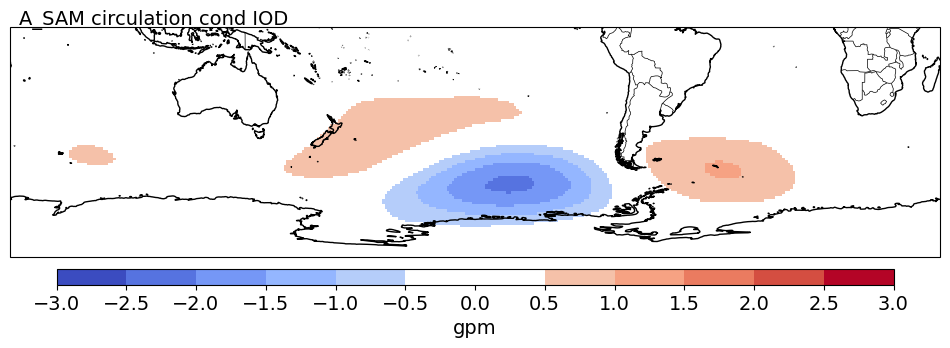

In [12]:
plot_map(1, z500_IOD_A_SAM_SON[0], 'IOD circulation total', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps_whole/IOD_Z500_total_copy.jpg')

plot_map(1, z500_IOD_A_SAM_SON[1], 'A_SAM circulation cond IOD', 'gpm', plt.figure(figsize=(12,7)), 1, cmap=plt.cm.coolwarm)
plt.savefig('regression_maps_whole/A_SAM_IOD_cond_Z500_total_copy.jpg')

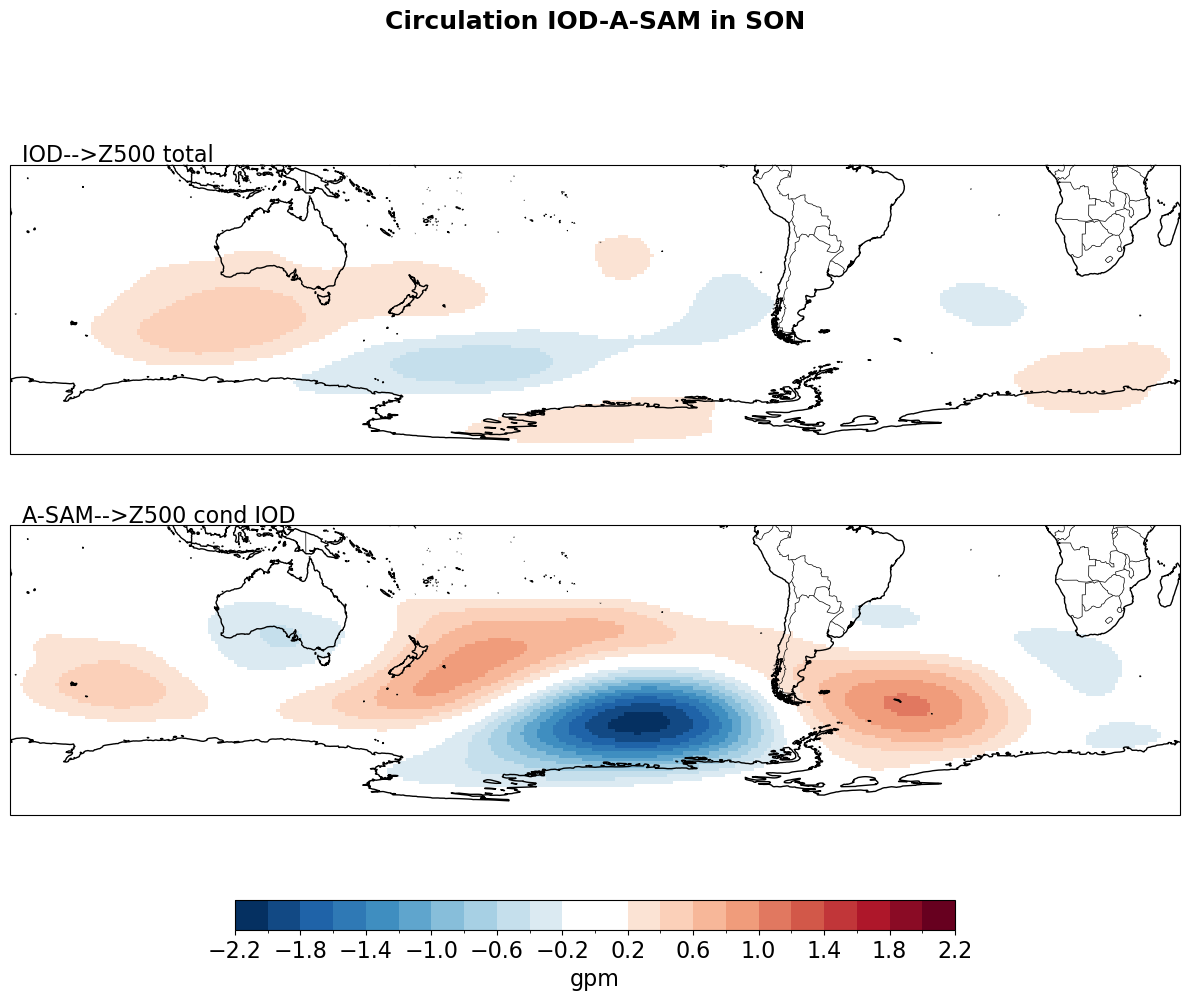

In [13]:
subplots_map(z500_IOD_A_SAM_SON, ['IOD-->Z500 total', 'A-SAM-->Z500 cond IOD'], cmap=plt.cm.RdBu.reversed(),\
             unit='gpm', steps=.2, heading='Circulation IOD-A-SAM in SON')

In [14]:
z500_all=conditioning_everything_fast(ds_SON, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'Z500')
z500_all_comp=[m.compute() for m in z500_all]

ENSO done
IOD done
SPV done
S_SAM done
A_SAM done


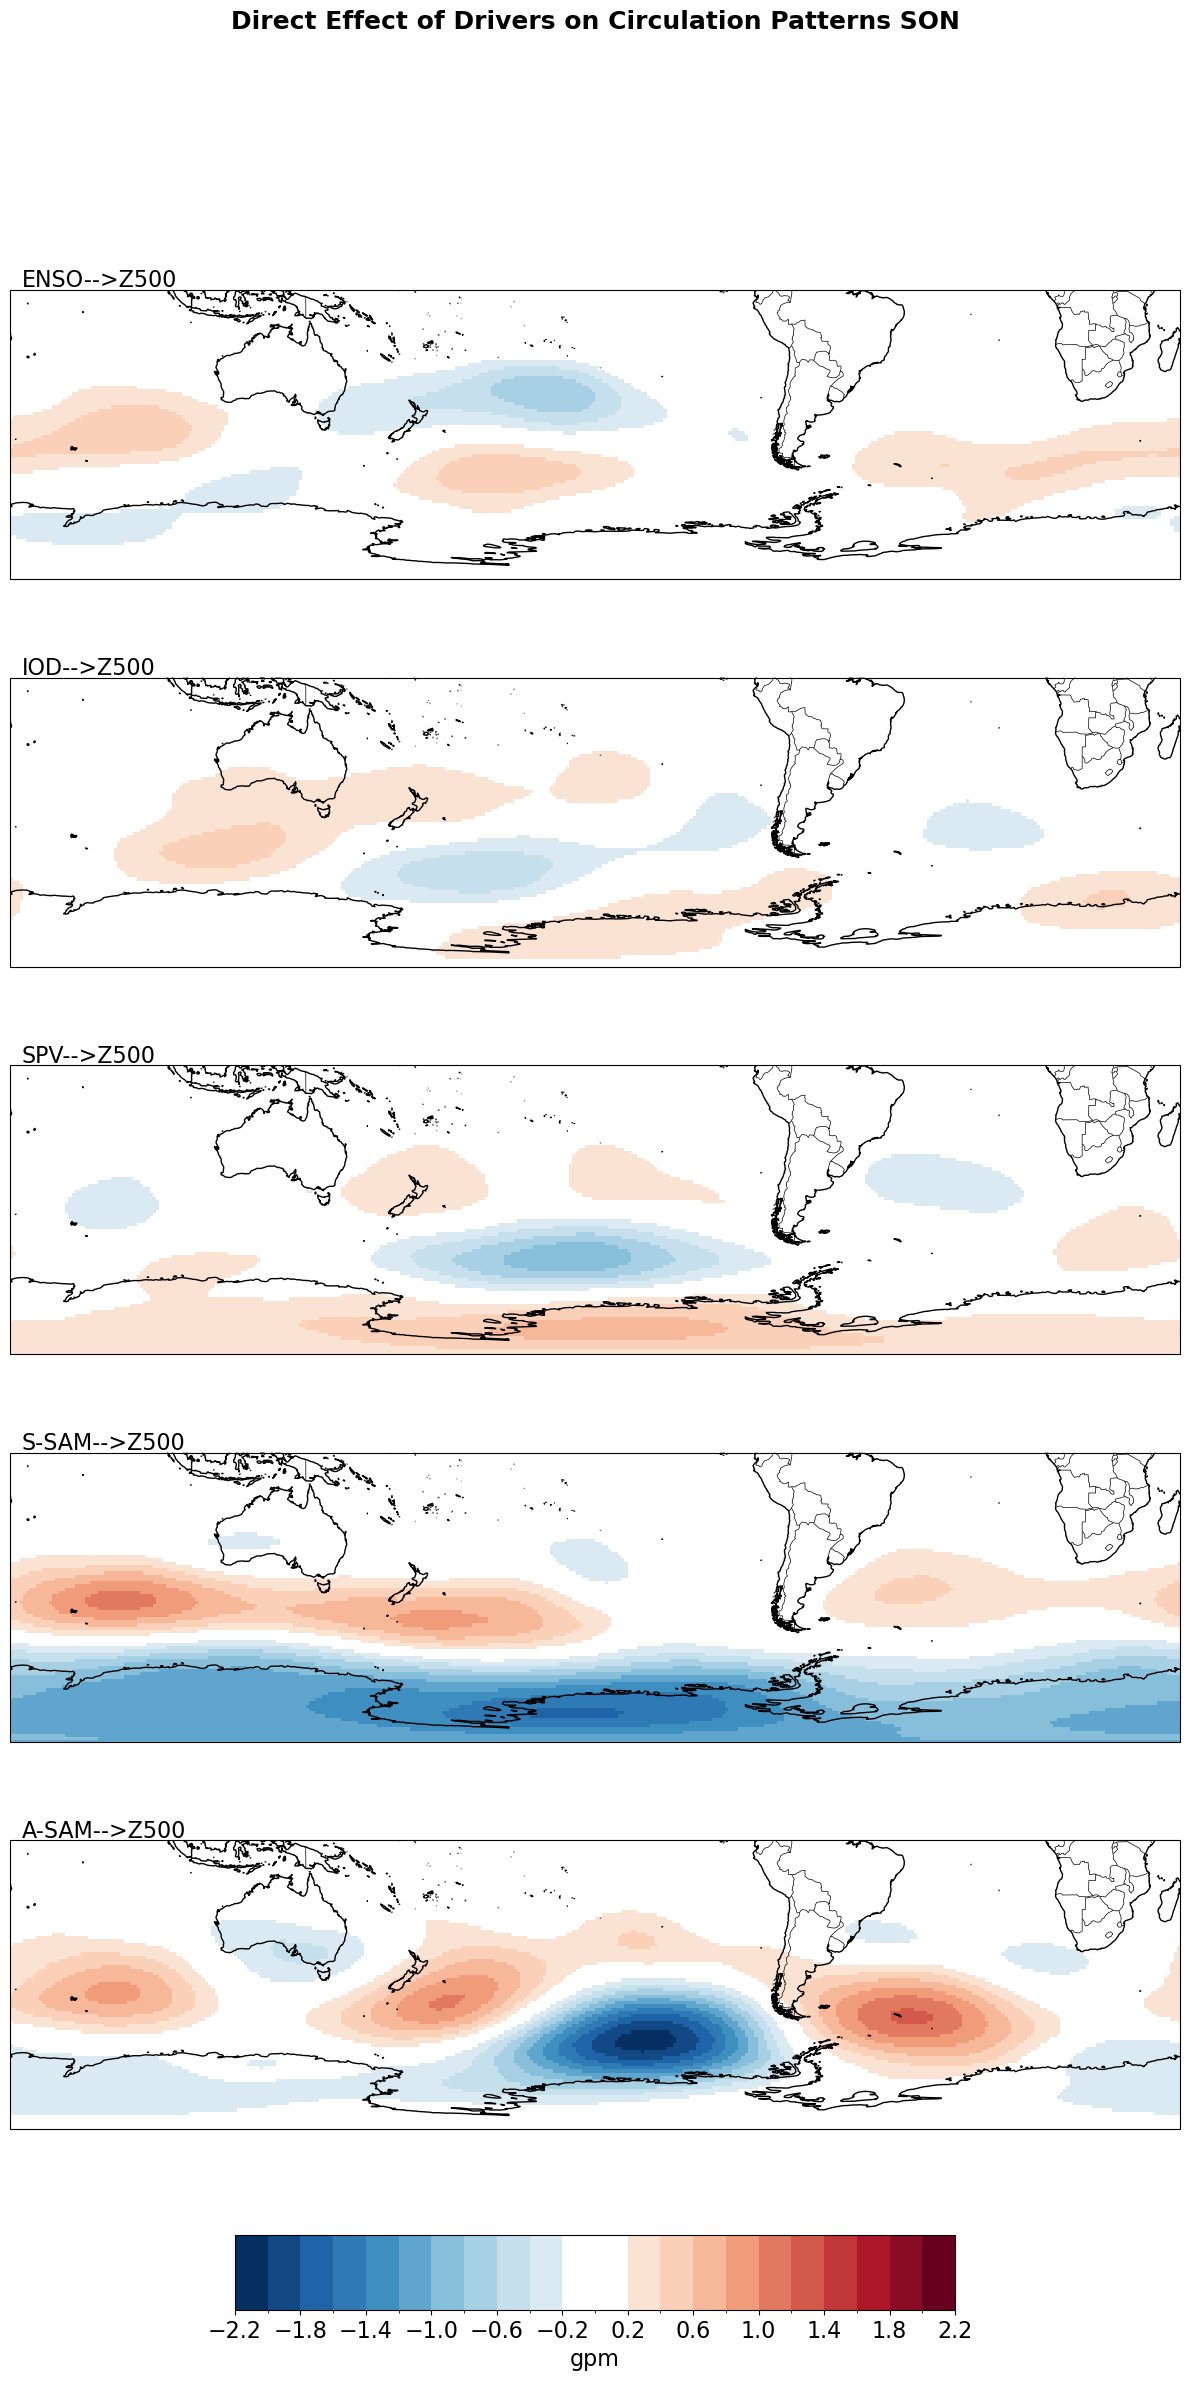

In [15]:
subplots_map(z500_all, ['ENSO-->Z500', 'IOD-->Z500','SPV-->Z500', 'S-SAM-->Z500','A-SAM-->Z500'], cmap=plt.cm.RdBu.reversed(),\
             unit='gpm', steps=.2, heading='Direct Effect of Drivers on Circulation Patterns SON')

In [16]:
z500_IOD_SON = conditioning_everything_fast(ds_SON, ['IOD'],'Z500')
z500_IOD_SON=[m.compute() for m in z500_IOD_SON]

IOD done


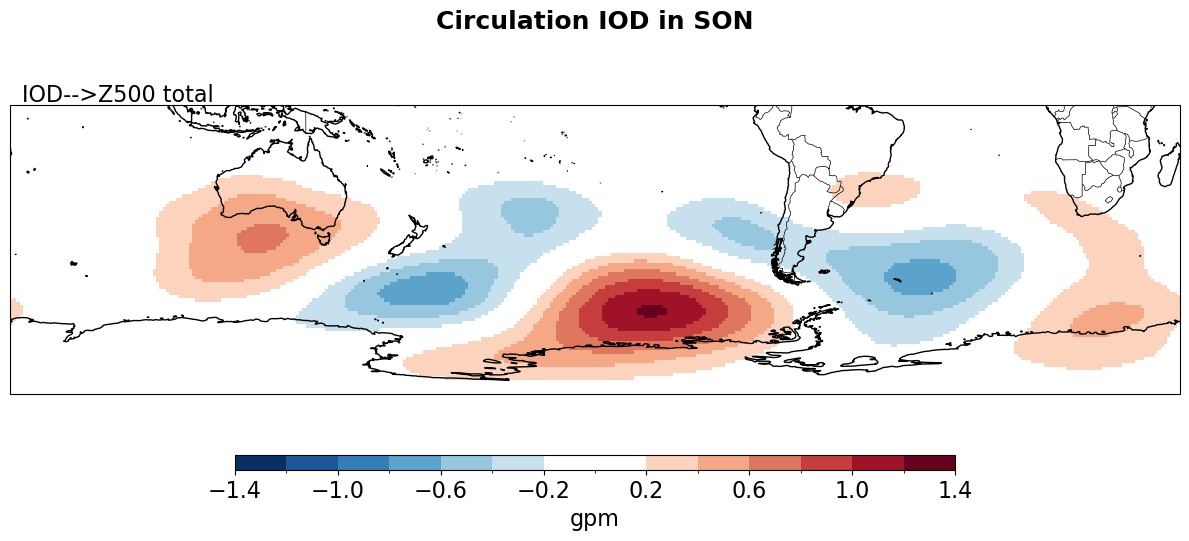

In [17]:
subplots_map(z500_IOD_SON, ['IOD-->Z500 total'], cmap=plt.cm.RdBu.reversed(),\
             unit='gpm', steps=.2, heading='Circulation IOD in SON')


Summer starts here DJF!

In [18]:
z500_all_DJF=conditioning_everything_fast(ds_DJF, ['ENSO','IOD','SPV', 'S_SAM','A_SAM'], 'Z500')
z500_all_comp_DJF=[m.compute() for m in z500_all_DJF]

ENSO done


IOD done
SPV done
S_SAM done
A_SAM done


In [19]:
z500_all_comp_DJF

[<xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[0.1097237 , 0.10976822, 0.1098509 , ..., 0.10938346, 0.10949238,
         0.10956169],
        [0.10615981, 0.10650337, 0.1067533 , ..., 0.10536986, 0.10562752,
         0.10590574],
        [0.10465143, 0.10503332, 0.10537438, ..., 0.10350647, 0.10387767,
         0.10428247],
        ...,
        [0.31685711, 0.31879243, 0.32087963, ..., 0.31266457, 0.31373002,
         0.31514147],
        [0.3179828 , 0.31986322, 0.32190571, ..., 0.31415846, 0.31500006,
         0.31632145],
        [0.31862132, 0.32058653, 0.32262996, ..., 0.31486098, 0.31588186,
         0.31705854]], shape=(90, 360))
 Coordinates:
   * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
   * lat      (lat) float64 720B -89.5 -88.5 -87.5 -86.5 ... -3.5 -2.5 -1.5 -0.5,
 <xarray.DataArray (lat: 90, lon: 360)> Size: 259kB
 array([[-0.16817479, -0.16806486, -0.16791983, ..., -0.1685471 ,
         -0.16842671, -0.16827954],
        [

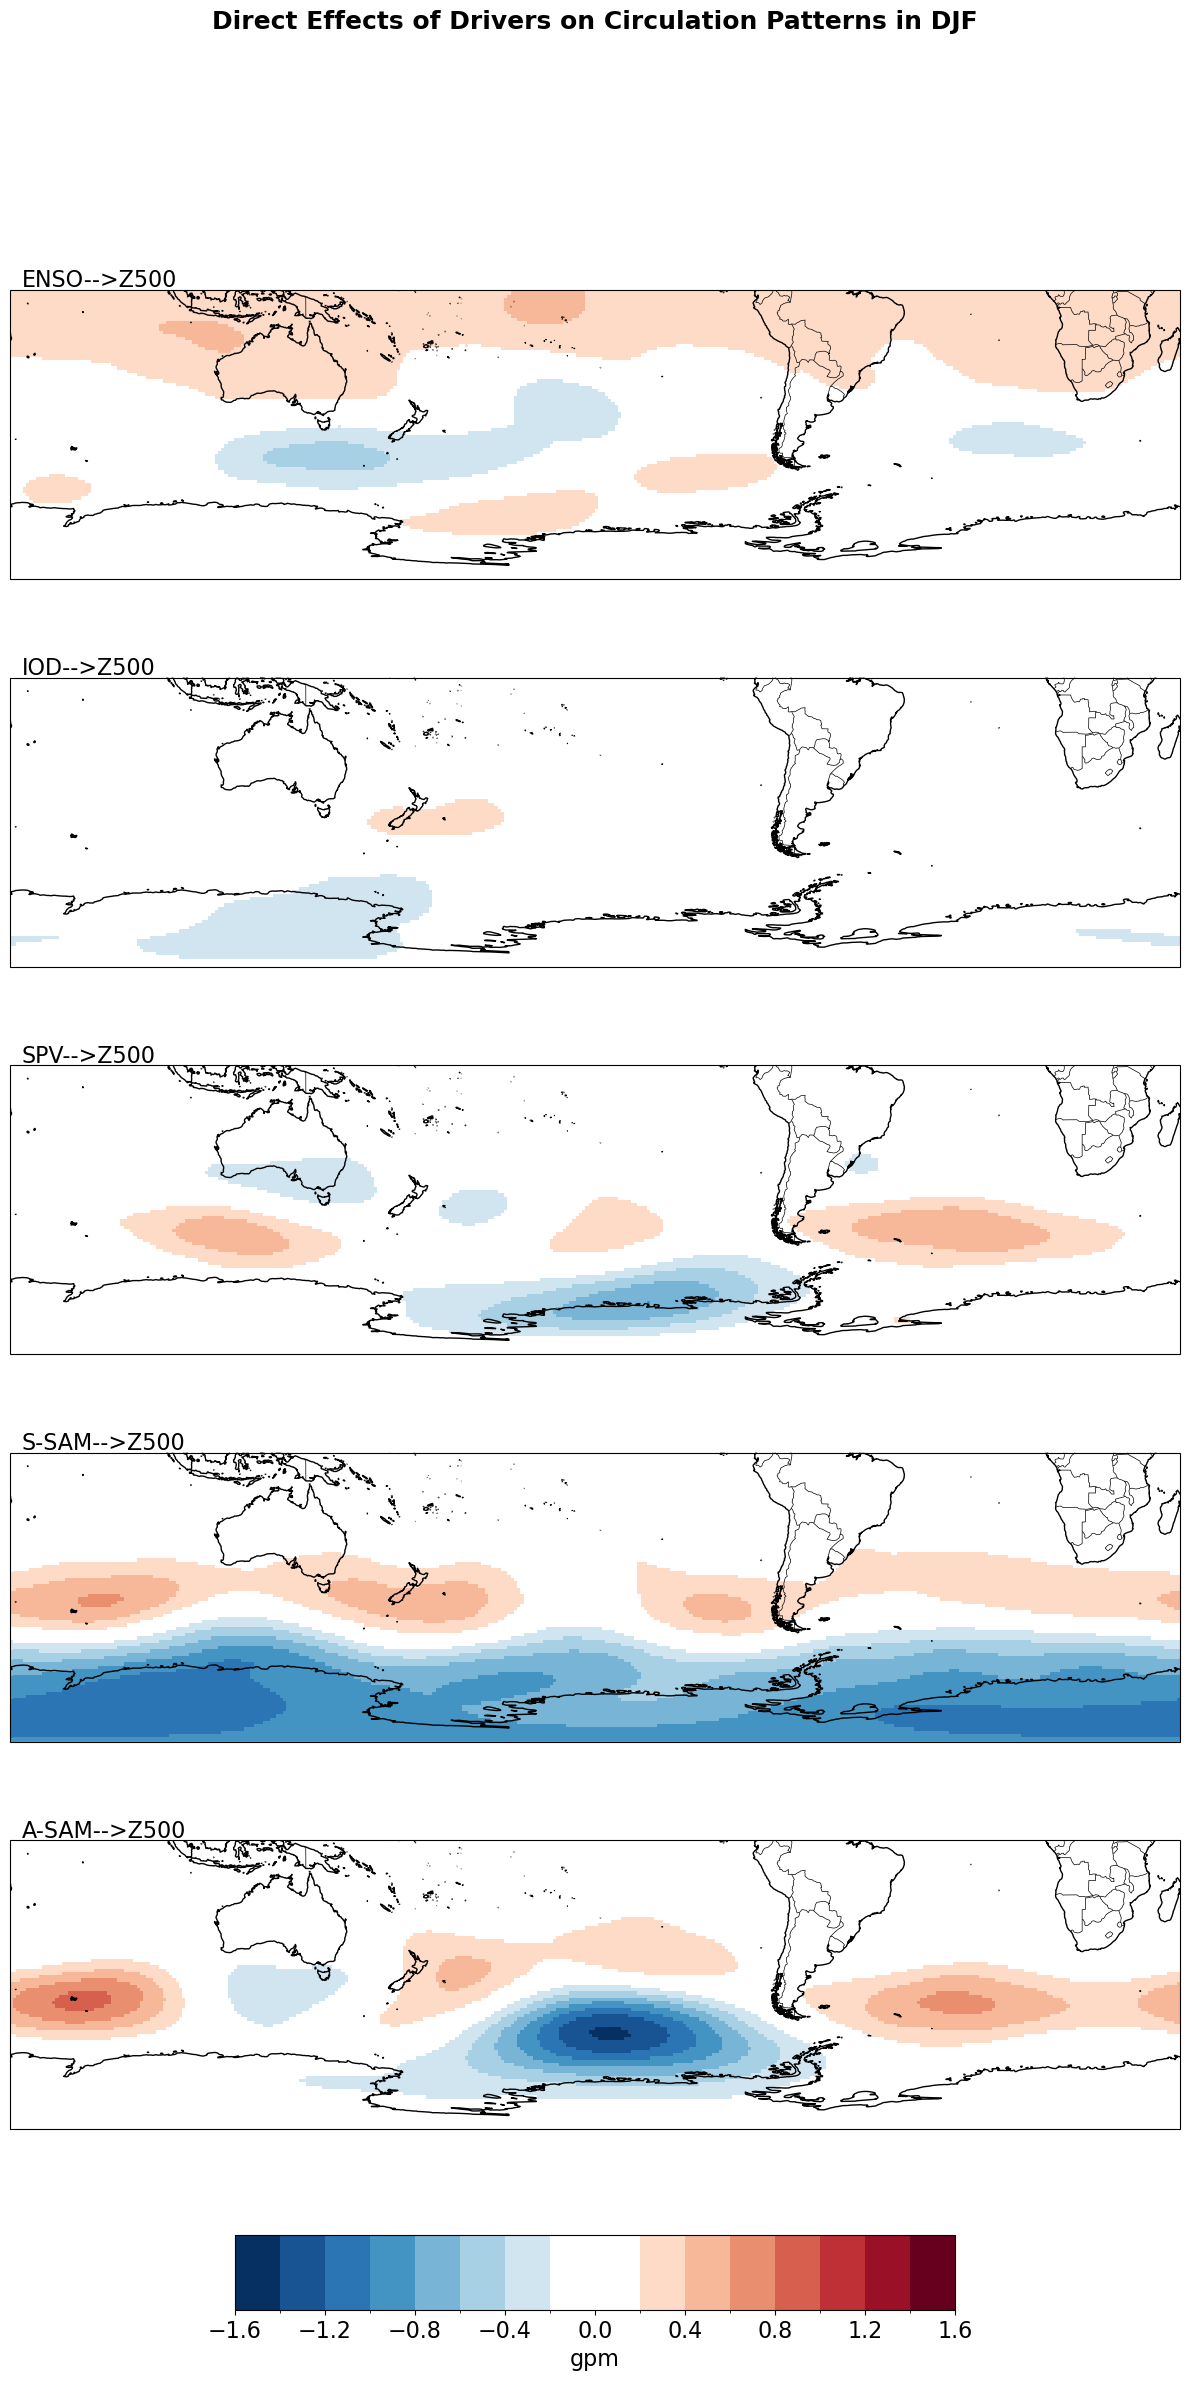

In [20]:
subplots_map(z500_all_comp_DJF, ['ENSO-->Z500', 'IOD-->Z500','SPV-->Z500','S-SAM-->Z500', 'A-SAM-->Z500']\
             , cmap=plt.cm.RdBu.reversed(),\
             unit='gpm', steps=.2, heading='Direct Effects of Drivers on Circulation Patterns in DJF')


In [21]:
z500_all_new = conditioning_everything_fast(ds_DJF, ['ENSO','IOBW', 'VB', 'S_SAM', 'A_SAM'],'Z500')
z500_all_comp_DJF_new=[m.compute() for m in z500_all_new]

ENSO done
IOBW done
VB done
S_SAM done
A_SAM done


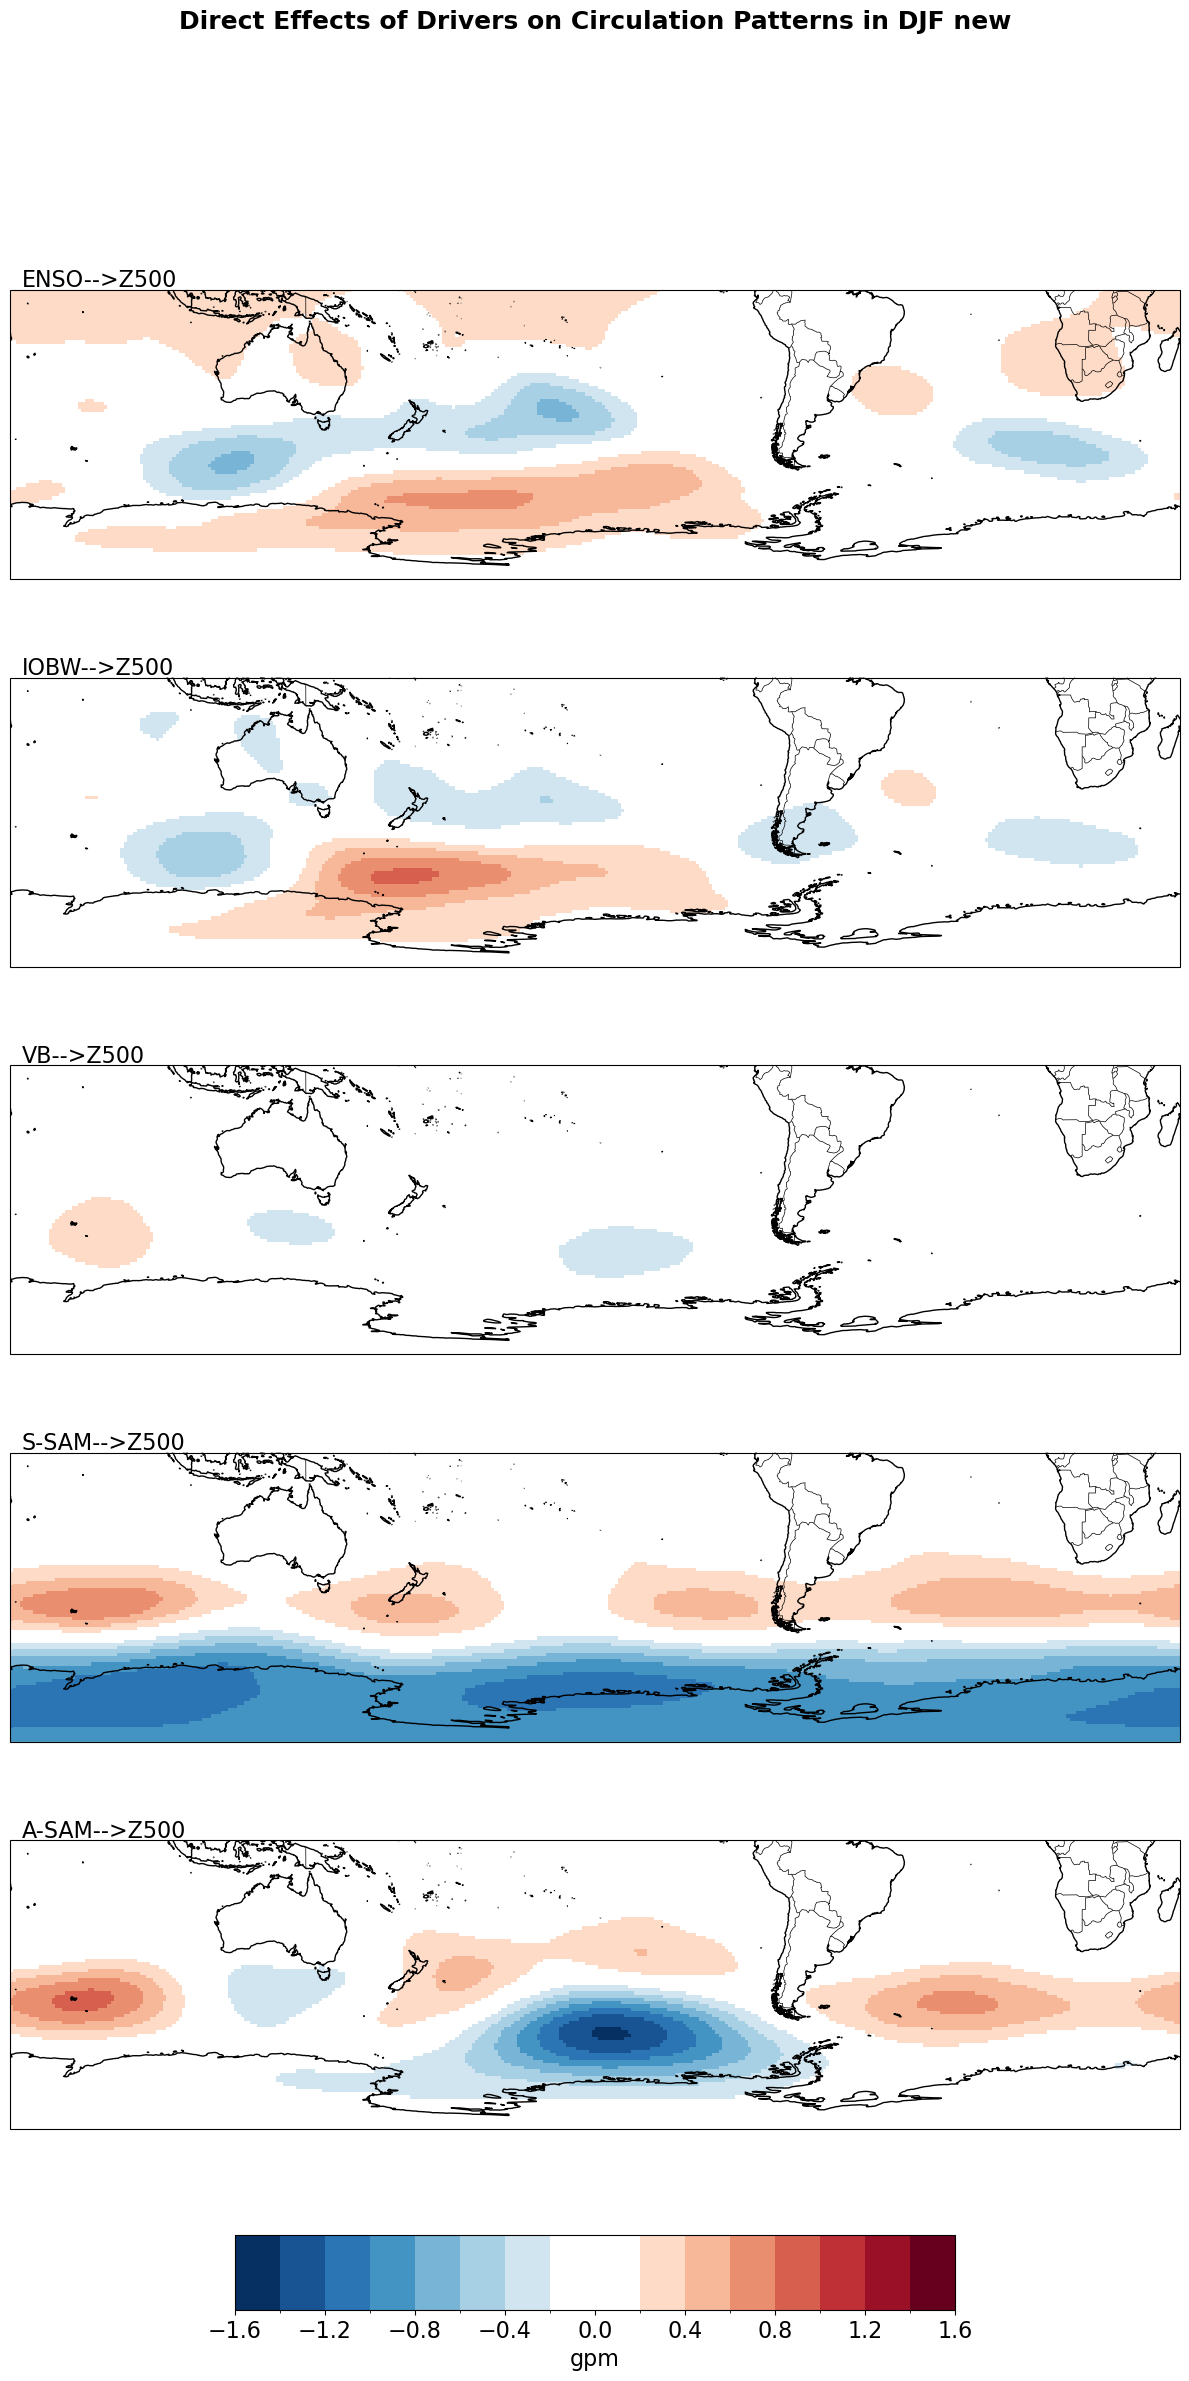

In [22]:
subplots_map(z500_all_comp_DJF_new, ['ENSO-->Z500', 'IOBW-->Z500','VB-->Z500', 'S-SAM-->Z500', 'A-SAM-->Z500'], cmap=plt.cm.RdBu.reversed(),\
             unit='gpm', steps=.2, heading='Direct Effects of Drivers on Circulation Patterns in DJF new')

In [25]:
z500_all_tot_DJF=conditioning_everything_fast(ds_DJF, ['ENSO','IOD','SPV'],\
                                               'Z500', total_eff=True)
z500_all_tot_comp_DJF=[m.compute() for m in z500_all_tot_DJF]

z500_all_tot_DJF_new=conditioning_everything_fast(ds_DJF, ['ENSO','IOBW','VB'],\
                                               'Z500', total_eff=True)
z500_all_tot_comp_DJF_new=[m.compute() for m in z500_all_tot_DJF_new]

ENSO done
IOD done
SPV done
ENSO done
IOBW done
VB done


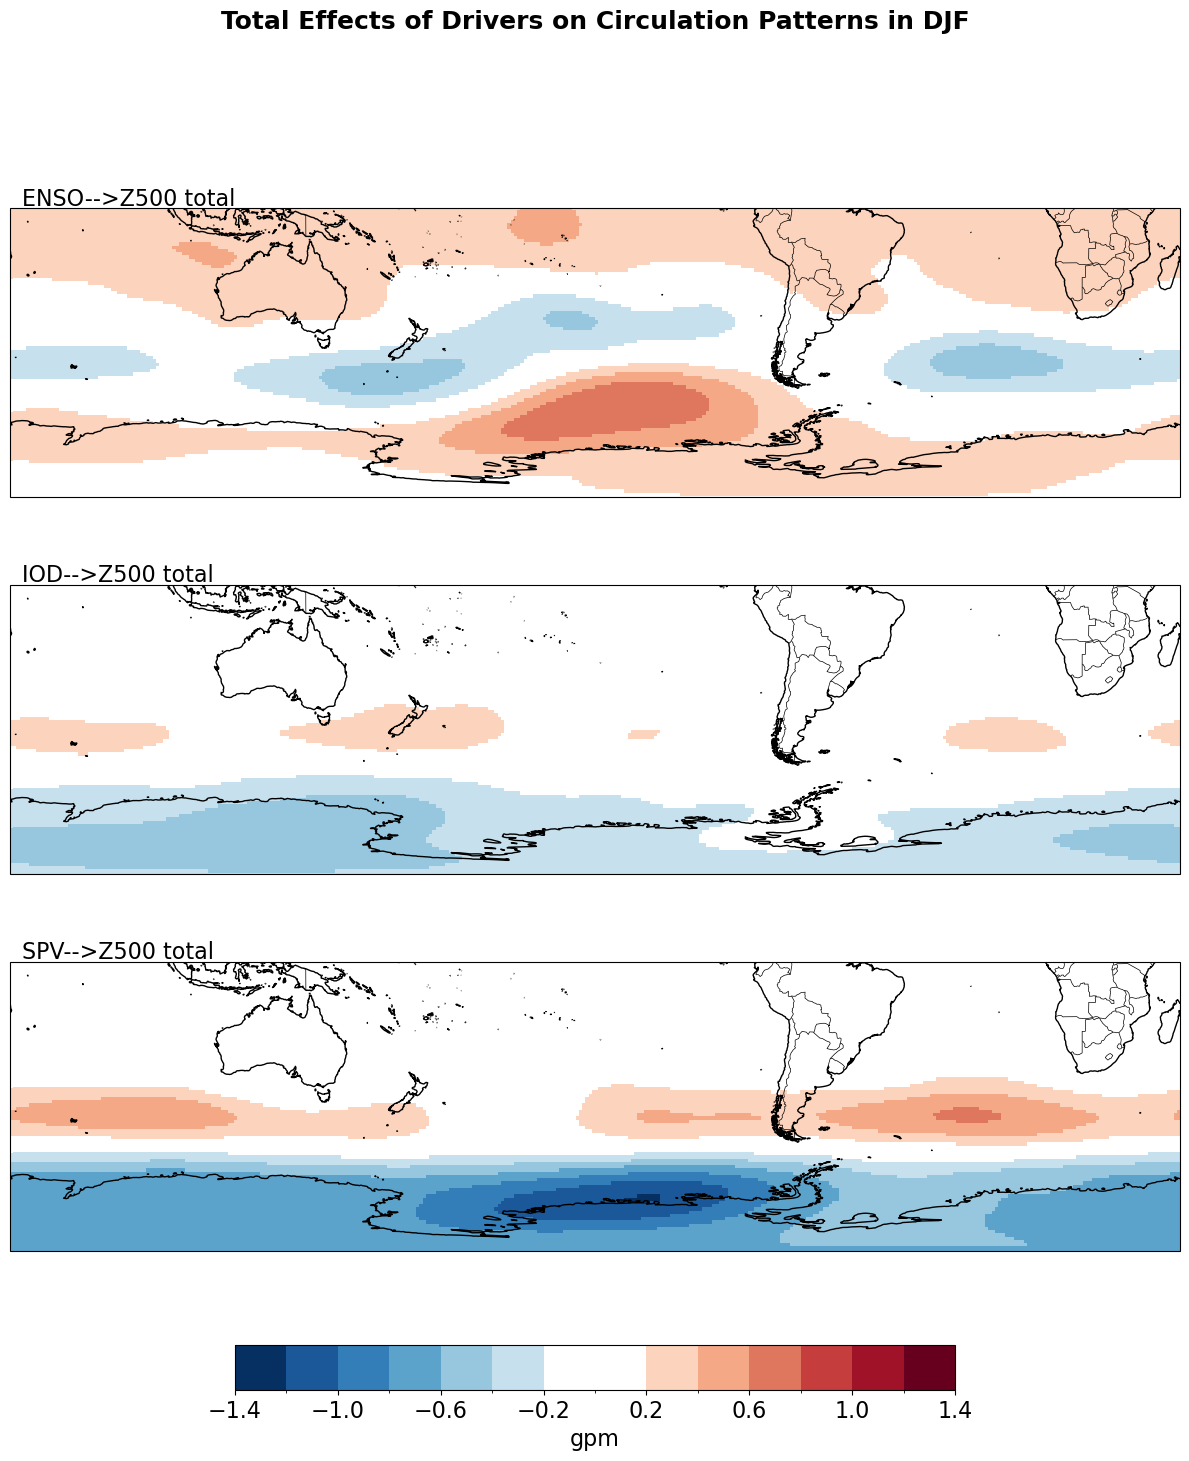

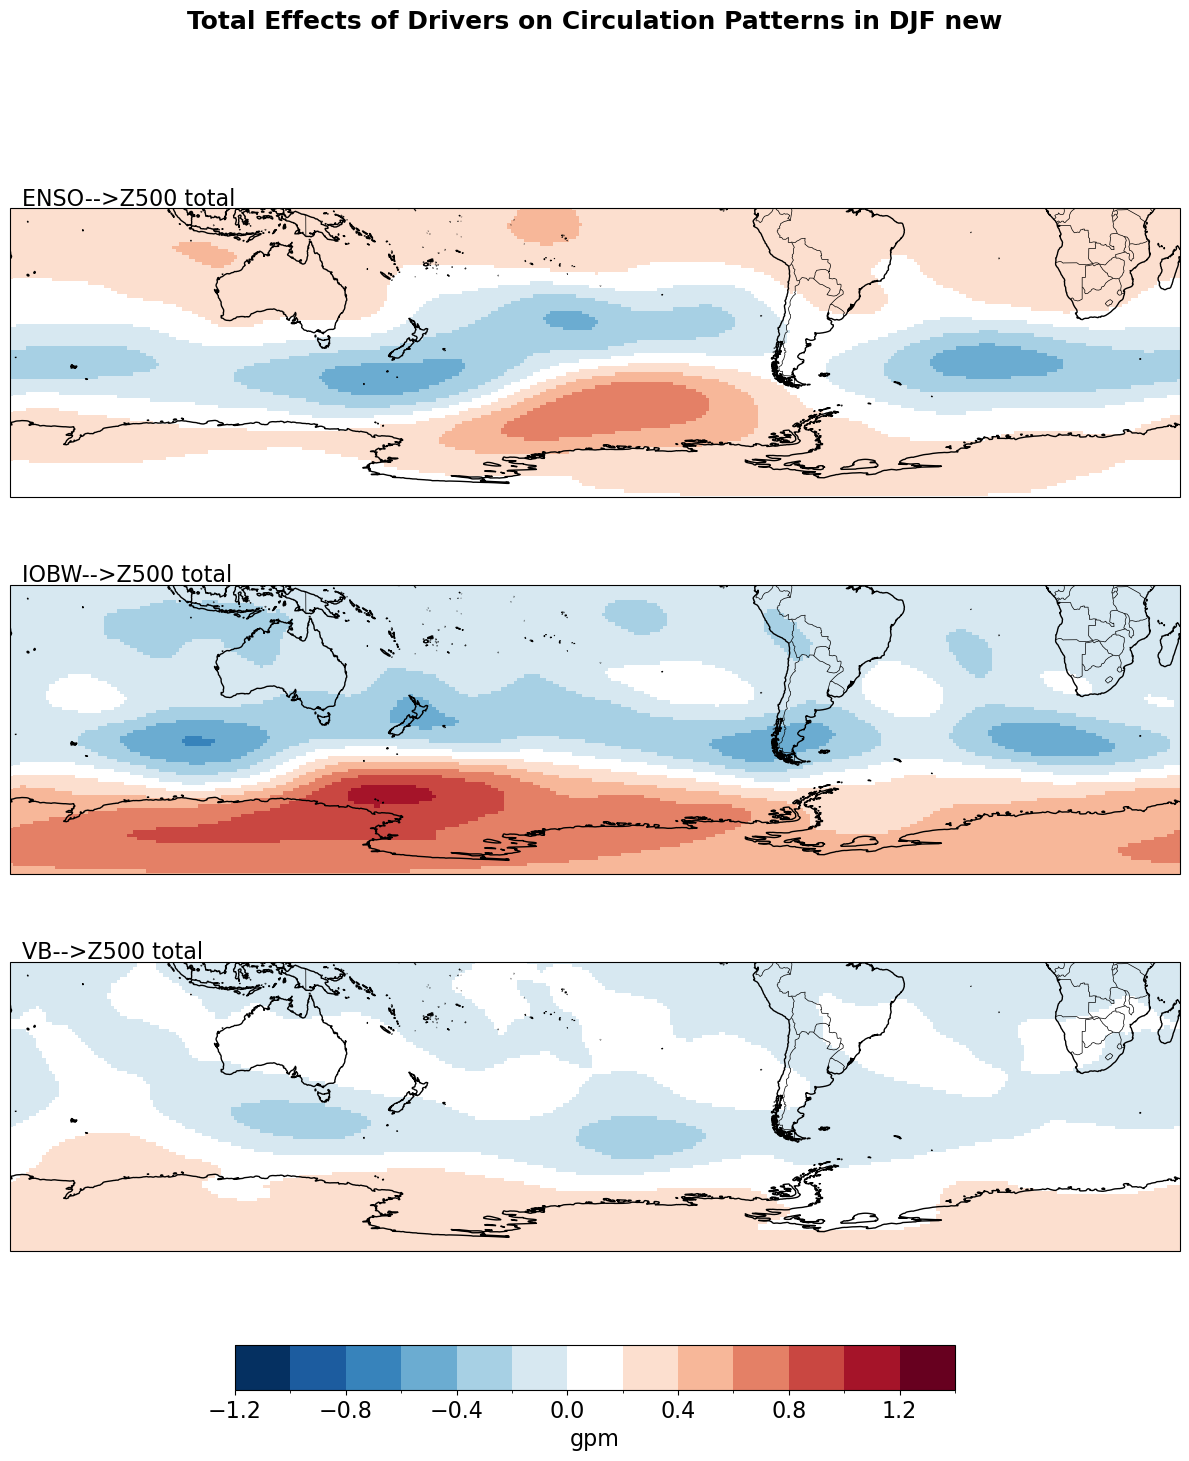

In [26]:
subplots_map(z500_all_tot_comp_DJF, ['ENSO-->Z500 total', 'IOD-->Z500 total','SPV-->Z500 total'],\
             cmap=plt.cm.RdBu.reversed(), unit='gpm', steps=.2, heading='Total Effects of Drivers on Circulation Patterns in DJF')
subplots_map(z500_all_tot_comp_DJF_new, ['ENSO-->Z500 total', 'IOBW-->Z500 total','VB-->Z500 total'],\
             cmap=plt.cm.RdBu.reversed(), unit='gpm', steps=.2, heading='Total Effects of Drivers on Circulation Patterns in DJF new')